In [48]:
### Thafat KANEM & Yanis MORIN ###
###   EPSI NANTES 30/01/2026   ###
###      TP Documentation      ###
### -------------------------- ###
###  Traitement, affichage des ###
###   données, statistiques,   ###
###    graphs, feature cards,  ###
###         datacards.         ###

In [49]:
# Imports
import pandas as pd
import json
import yaml
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [50]:
# Affichage des données
df = pd.read_csv("data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [51]:
#Calcul de la moyenne entre reading_score et writing_score dans une nouvelle variable "language mean score"
df["language mean score"] = df[["reading score", "writing score"]].mean(axis=1)
df.to_csv("data/StudentsPerformance_modified.csv", index=False)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,language mean score
0,female,group B,bachelor's degree,standard,none,72,72,74,73.0
1,female,group C,some college,standard,completed,69,90,88,89.0
2,female,group B,master's degree,standard,none,90,95,93,94.0
3,male,group A,associate's degree,free/reduced,none,47,57,44,50.5
4,male,group C,some college,standard,none,76,78,75,76.5


In [52]:
#Affichage des missing values
dict_df = pd.DataFrame([
    {
        "column": col,
        "type": str(df[col].dtype),
        "unique_values": df[col].nunique(),
        "sample_values": df[col].dropna().unique()[:5].tolist(),
        "missing_values": df[col].isna().sum()
    }
    for col in df.columns
])
dict_df

,column,type,unique_values,sample_values,missing_values
0,gender,object,2,"[female, male]",0
1,race/ethnicity,object,5,"[group B, group C, group A, group D, group E]",0
2,parental level of education,object,6,"[bachelor's degree, some college, master's deg...",0
3,lunch,object,2,"[standard, free/reduced]",0
4,test preparation course,object,2,"[none, completed]",0
5,math score,int64,81,"[72, 69, 90, 47, 76]",0
6,reading score,int64,72,"[72, 90, 95, 57, 78]",0
7,writing score,int64,77,"[74, 88, 93, 44, 75]",0
8,language mean score,float64,138,"[73.0, 89.0, 94.0, 50.5, 76.5]",0


In [53]:
# Valeurs manquantes
missing = df.isna().sum()

# Doublons
duplicates = df.duplicated().sum()

# Biais simples (ex: déséquilibre d'une variable catégorique, proportion femme/homme, etc)
gender_bias = df['gender'].value_counts(normalize=True)
race_bias = df['race/ethnicity'].value_counts(normalize=True)

missing, duplicates, gender_bias, race_bias

(gender                         0
 race/ethnicity                 0
 parental level of education    0
 lunch                          0
 test preparation course        0
 math score                     0
 reading score                  0
 writing score                  0
 language mean score            0
 dtype: int64,
 np.int64(0),
 gender
 female    0.518
 male      0.482
 Name: proportion, dtype: float64,
 race/ethnicity
 group C    0.319
 group D    0.262
 group B    0.190
 group E    0.140
 group A    0.089
 Name: proportion, dtype: float64)

In [54]:
#Moyenne, min, max, médiane
numeric_stats = df.describe().T[['mean','min','max','50%']]
numeric_stats.rename(columns={'50%': 'median'}, inplace=True)
numeric_stats

,mean,min,max,median
math score,66.0890,0.0,100.0,66.0
reading score,69.1690,17.0,100.0,70.0
writing score,68.0540,10.0,100.0,69.0
language mean score,68.6115,13.5,100.0,69.5


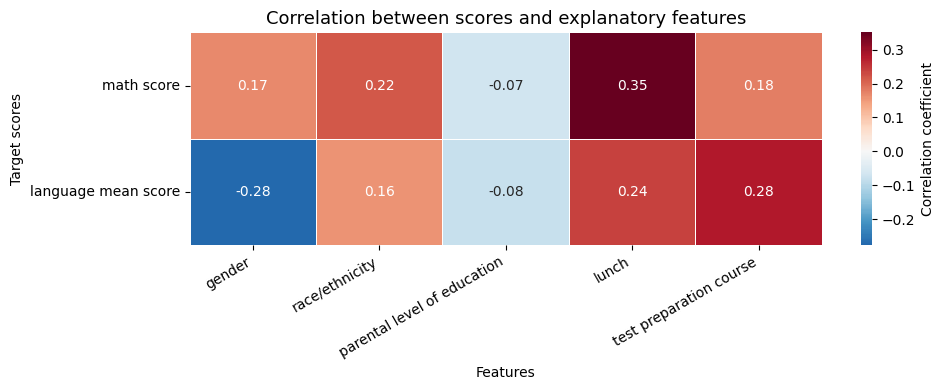

,gender,race/ethnicity,parental level of education,lunch,test preparation course
math score,0.167982,0.216415,-0.068279,0.350877,0.177702
language mean score,-0.276493,0.157473,-0.079396,0.240572,0.281284


In [55]:
# Matrice de corr + export CSV + affichage graphique
df_corr = df.copy()
df_corr["gender"] = df_corr["gender"].map({"female": 0, "male": 1})
df_corr["race/ethnicity"] = df_corr["race/ethnicity"].astype("category").cat.codes
df_corr["parental level of education"] = df_corr["parental level of education"].astype("category").cat.codes
df_corr["lunch"] = df_corr["lunch"].astype("category").cat.codes
df_corr["test preparation course"] = df_corr["test preparation course"].map({"none": 0, "completed": 1})

# Sélection uniquement des 2 cibles "math score" et "language mean score" + 5 features "gender", "race/ethnicity", 
# "parental level of education", "lunch", "test preparation course"
cols = ["math score", "language mean score", "gender", "race/ethnicity",
        "parental level of education", "lunch", "test preparation course"]

corr = df_corr[cols].corr()

# Extraction des corrélations des 2 scores contre les 5 features
corr_math = corr.loc[["math score"], cols[2:]]
corr_lang = corr.loc[["language mean score"], cols[2:]]

# Concaténation pour export propre
corr_final = pd.concat([corr_math, corr_lang])

# Export CSV
corr_final.to_csv("data/StudentsPerformance_correlation_matrix.csv", index=True)

# Heatmap print
plt.figure(figsize=(10, 4))

sns.heatmap(
    corr_final,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between scores and explanatory features", fontsize=13)
plt.xlabel("Features")
plt.ylabel("Target scores")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

corr_final

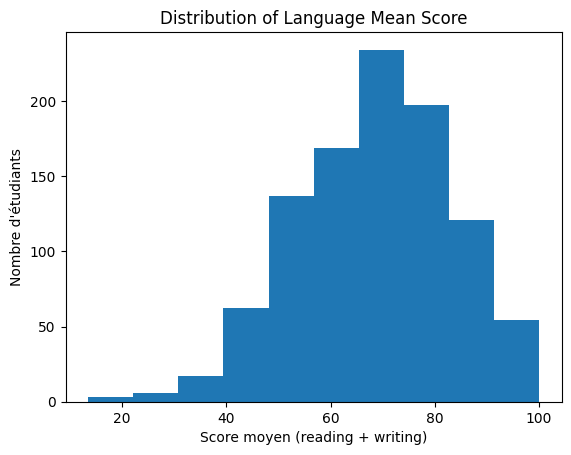

In [56]:
#Distribution de language mean score
plt.figure()
plt.hist(df["language mean score"])
plt.title("Distribution of Language Mean Score")
plt.xlabel("Score moyen (reading + writing)")
plt.ylabel("Nombre d'étudiants")
plt.show()

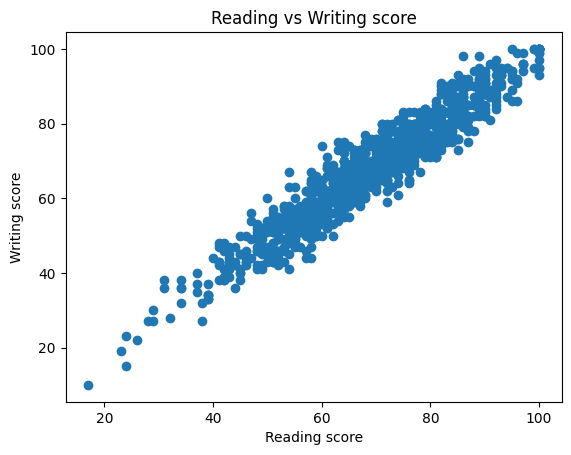

In [57]:
# Nuage de points corrélation linéaire entre reading et writing score
plt.figure()
plt.scatter(df["reading score"], df["writing score"])
plt.title("Reading vs Writing score")
plt.xlabel("Reading score")
plt.ylabel("Writing score")
plt.show()

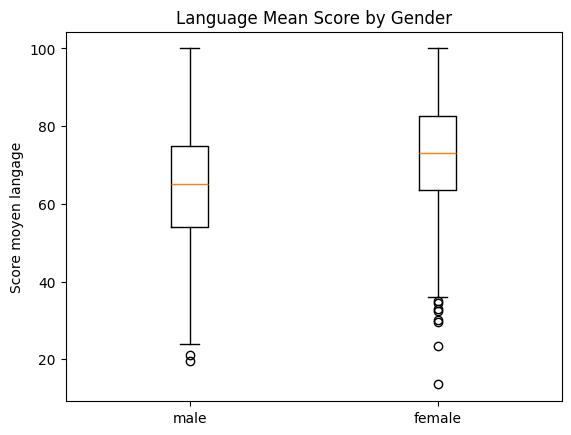

In [58]:
#Boite à moustaches sur language mean score en fonction du genre.
if "gender" in df.columns:
    plt.figure()
    for g, group in df.groupby("gender"):
        plt.boxplot(group["language mean score"], positions=[0 if g=="male" else 1])
    plt.xticks([0,1], ["male", "female"])
    plt.title("Language Mean Score by Gender")
    plt.ylabel("Score moyen langage")
    plt.show()

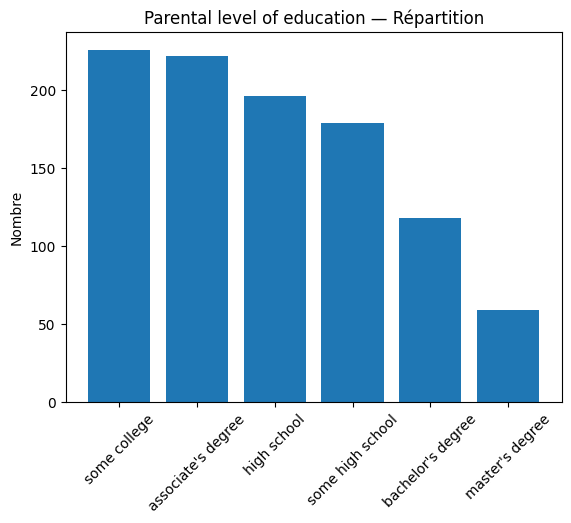

In [59]:
# Répartition du niveau d'éducation parental par élève
if "parental level of education" in df.columns:
    counts = df["parental level of education"].value_counts()
    plt.figure()
    plt.bar(range(len(counts)), counts)
    plt.xticks(range(len(counts)), counts.index, rotation=45)
    plt.title("Parental level of education — Répartition")
    plt.ylabel("Nombre")
    plt.show()

In [60]:
#Feature cards
df = pd.read_csv("data/StudentsPerformance_modified.csv")

descriptions = {
    "gender": "Sexe déclaré de l’étudiant",
    "race/ethnicity": "Groupe ethnique déclaré (catégories A–E)",
    "parental level of education": "Niveau d’étude du/des parent(s)",
    "lunch": "Type de repas (standard vs free/reduced)",
    "test preparation course": "Préparation au test (aucune vs complétée)",
    "math score": "Score en mathématiques",
    "reading score": "Score en compréhension écrite",
    "writing score": "Score en expression écrite",
    "language mean score": "Moyenne des scores reading et writing"
}

os.makedirs("data/feature_cards", exist_ok=True)

feature_cards = {}

for col in df.columns:
    s = df[col]
    card = {
        "feature": col,
        "description": descriptions.get(col, ""),
        "dtype": str(s.dtype),
        "missing_values": int(s.isna().sum()),
        "missing_rate": float(s.isna().mean()),
        "unique_values": int(s.nunique(dropna=True)),
    }

    if pd.api.types.is_numeric_dtype(s):
        q1, q3 = float(s.quantile(0.25)), float(s.quantile(0.75))
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

        card.update({
            "unit": "score (0–100)" if "score" in col.lower() else "",
            "min": float(s.min()),
            "max": float(s.max()),
            "mean": float(s.mean()),
            "median": float(s.median()),
            "std": float(s.std()),
            "quartiles": {"q1": q1, "q3": q3, "iqr": float(iqr)},
            "outliers_iqr_count": int(((s < lower) | (s > upper)).sum()),
            "sample_values": s.dropna().head(5).tolist()
        })
    else:
        vc = s.value_counts(dropna=True).head(5)
        card.update({
            "categories_top5": {str(k): int(v) for k, v in vc.items()},
            "categories_top5_rate": {str(k): float(v/len(s)) for k, v in vc.items()},
            "sample_values": s.dropna().unique()[:5].tolist()
        })

    feature_cards[col] = card

    filename = col.replace("/", "_").replace(" ", "_").lower() + ".json"
    with open(os.path.join("data/feature_cards", filename), "w", encoding="utf-8") as f:
        json.dump(card, f, indent=2, ensure_ascii=False)

print("Feature cards générées + sauvegardées dans data/feature_cards/")

Feature cards générées + sauvegardées dans data/feature_cards/


In [61]:
#Datacards
# Chemins
data_card_path = Path("data/data_card.yaml")

# Charge YAML existant
if data_card_path.exists():
    with open(data_card_path, "r", encoding="utf-8") as f:
        data_card = yaml.safe_load(f) or {}
else:
    data_card = {}

# Liens vers feature cards
feature_links = {
    col: f"data/feature_cards/{col.replace('/', '_').replace(' ', '_').lower()}.json"
    for col in df.columns
}

# Métadonnées globales (regroupées)
data_card["name"] = "Students Performance"
data_card["version"] = "1.0"
data_card["domain"] = "education"
data_card["created"] = "2026-01-08"
data_card["intended_use"] = "Analyse et recommandation des performances étudiantes"
data_card["data_source"] = "Collecté par enquêtes scolaires anonymisées"
data_card["coverage"] = "Étudiants — performances académiques"
data_card["collection_method"] = "Fichier fourni par un établissement éducatif"
data_card["period_covered"] = "Non temporel (instantané)"

# Section Feature Cards
data_card["feature_cards"] = {
    "format": "json",
    "directory": "data/feature_cards/",
    "files": feature_links
}

feature_details = {}

for col, rel_path in feature_links.items():
    path = Path(rel_path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            feature_details[col] = json.load(f)
    else:
        feature_details[col] = {"warning": f"Feature card file not found: {rel_path}"}

data_card["feature_cards"]["details"] = feature_details

# Section Artefacts (tous au même endroit)
data_card["artifacts"] = {
    "students_modified": "data/StudentsPerformance_modified.csv",
    "correlation_matrix": "data/StudentsPerformance_corr.csv",
    "correlation_heatmap_image": "Correlation matrix displayed in notebook"
}

# Écrit YAML final
with open(data_card_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_card, f, sort_keys=False, allow_unicode=True)

print("data_card.yaml mis à jour, tout est regroupé + lien corr ajouté.")

data_card.yaml mis à jour, tout est regroupé + lien corr ajouté.
